# **Dataset Heart Disease(1988)**
Ce dataset contient des données médicales provenant de 4 bases de données distincts : Cleveland, Hungary, Switzerland, et VA Long Beach. Mais pour ce projet c'est la base de donnée *Cleveland* qui sera utilisée.Il regroupe un total de **303 patients** avec leurs caractéristiques cliniques et leur diagnostic de maladie cardiaque.

**Source:** UCI Machine Learning Repository ([Cliquez ici pour voir le dataset](https://archive.ics.uci.edu/dataset/45/heart+disease))

**Objectif principal:**
Prédire si un patient a une maladie cardiaque ou non à partir de ses caractéristiques médicales (âge, sexe, pression artérielle, cholestérol, etc.).

**Caractéristique des données**

**Taille**:303 patients

**Nombre de variables:** 14(features+ target)

**Colonnes principales**

***age*** :Âge du patient (années)

***sex***	:Sexe (1=homme, 0=femme)

***cp***	:Type de douleur thoracique (1-4)

***trestbps*** :Pression artérielle au repos (mm Hg)

***chol***	:Cholestérol sérique (mg/dl)

***fbs*** :Glycémie à jeun > 120 mg/dl (1 = vrai, 0 = faux)

***restecg***	:Résultats électrocardiographiques au repos (0-2)

***thalach***	:Fréquence cardiaque maximale atteinte

***exang***	:Angine d’effort induite par l’exercice (1 = oui, 0 = non)

***oldpeak***	:Dépression ST induite par l’exercice par rapport au repos

***slope***	:Pente du segment ST d’exercice (1-3)

***ca*** :Nombre de vaisseaux principaux (0-3) colorés par fluoroscopie

***thal*** :3 = normal, 6 = défaut fixe, 7 = défaut réversible

***target*** :Présence de maladie cardiaque (0 = non, 1-4 = sévérité)


In [ ]:
from google.colab import files #je téléverse kaggle.json afin de me facilité la tâche avec les données
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle #Ici je configure kaggle dans google colab
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d johnsmith88/heart-disease-dataset #telecharger le dataset depuis kaggle

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
  0% 0.00/6.18k [00:00<?, ?B/s]
100% 6.18k/6.18k [00:00<00:00, 27.4MB/s]


In [ ]:
import zipfile#dezipper la donnée
zip_file = "heart-disease-dataset.zip"
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(".")

In [ ]:
import pandas as pd#importer le fichier cleveland du document
df = pd.read_csv("heart.csv")
print(df.shape)#pour voir le nombre de colonnes et de lignes du dataframe

(1025, 14)


In [ ]:
print(df.columns)#afficher le nom des colonnes

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [ ]:
df.head()#afficher un les 5 premières lignes du tableau.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()#afficher un les 5 premières lignes du tableau.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
df.info()#nombre de colonnes et leur type (int, float, object),voir s'il a des valeurs manquantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()#nombre de valeurs manquantes dans chaque colonne
df.duplicated().sum()#nombre de doublons

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## EDA

/tmp/ipython-input-3991988483.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set3')


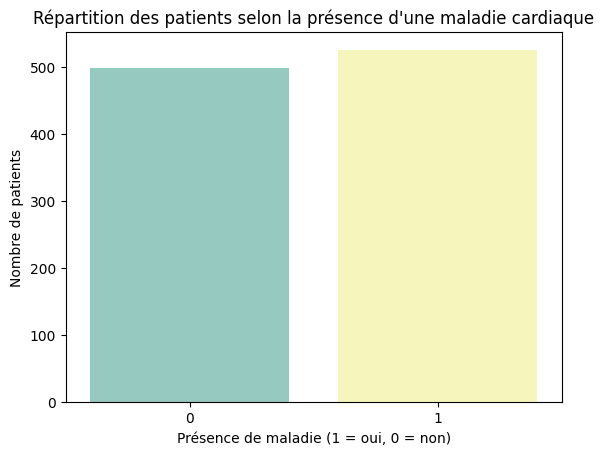

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x='target', palette='Set3')
plt.title("Répartition des patients selon la présence d'une maladie cardiaque")
plt.xlabel("Présence de maladie (1 = oui, 0 = non)")
plt.ylabel("Nombre de patients")
plt.show()

In [ ]:
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.513171
0,0.486829


In [ ]:
df['target'].value_counts()

,count
target,
1,526
0,499


/tmp/ipython-input-2935024342.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target',y='age',data=df,palette='Set2')


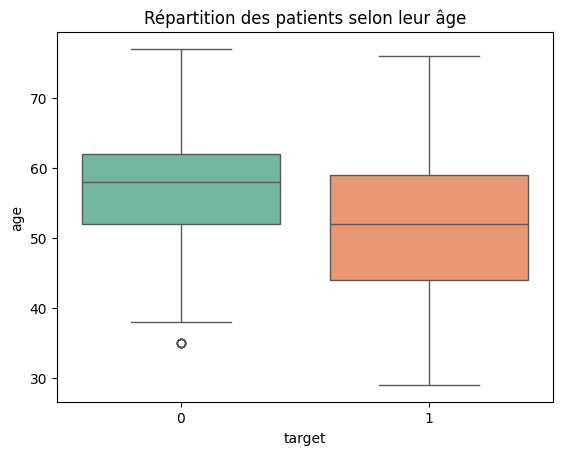

In [ ]:
sns.boxplot(x='target',y='age',data=df,palette='Set2')
plt.title('Répartition des patients selon leur âge')
plt.show()

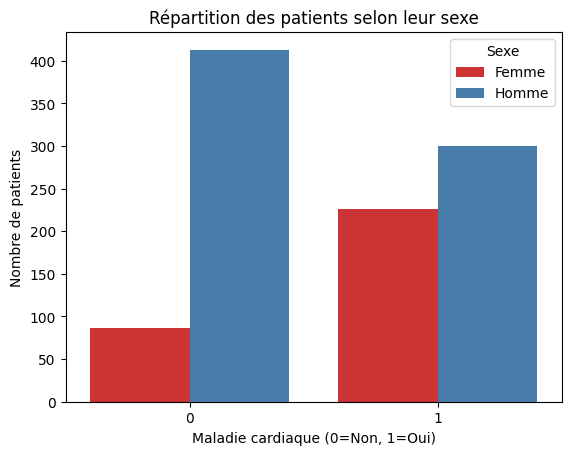

In [ ]:
# Avec un graphique en barres (countplot)
sns.countplot(x='target', hue='sex', data=df, palette='Set1')
plt.title('Répartition des patients selon leur sexe')
plt.xlabel('Maladie cardiaque (0=Non, 1=Oui)')
plt.ylabel('Nombre de patients')
plt.legend(title='Sexe', labels=['Femme', 'Homme'])
plt.show()

In [ ]:
# Nombre de femmes avec maladie cardiaque
femmes_malades = df[(df['sex'] == 0) & (df['target'] == 1)].shape[0]
print("Nombre de femmes malades :", femmes_malades)


Nombre de femmes malades : 226


In [ ]:
#Nombre d'hommes avec maladie cardiaque
homme_malades= df[(df['sex'] == 1) & (df['target'] == 1)].shape[0]
print("Nombre d'hommes malades:",homme_malades)

Nombre d'hommes malades: 300


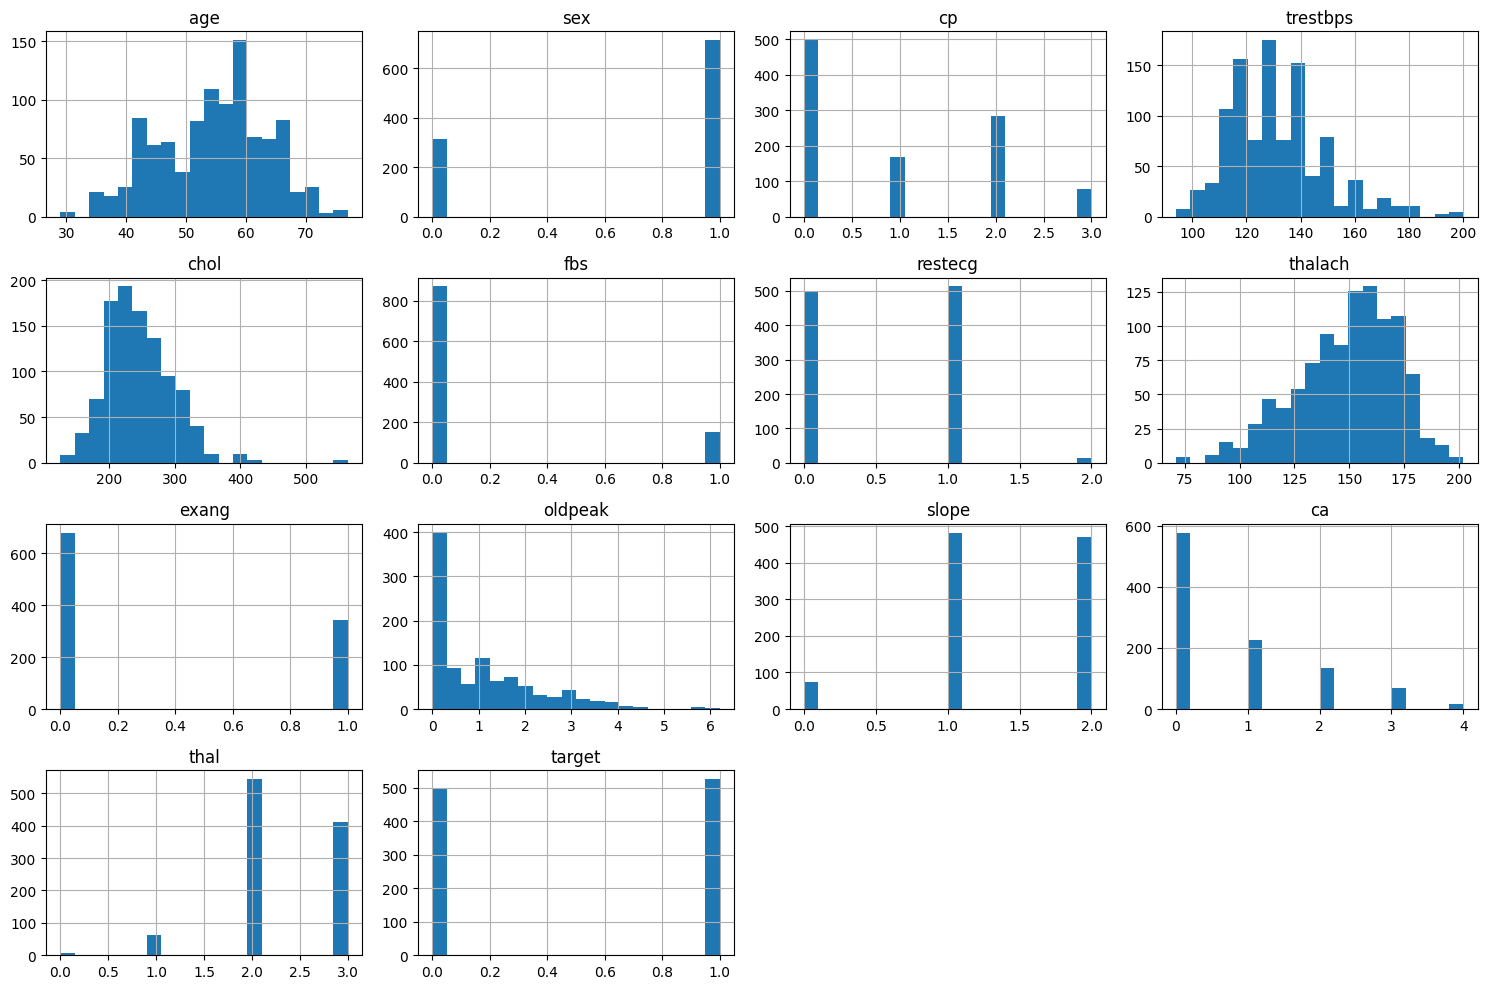

In [ ]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
original_columns = df.columns.copy()#conserver la structure initiale du jeu de donnée

Correlation

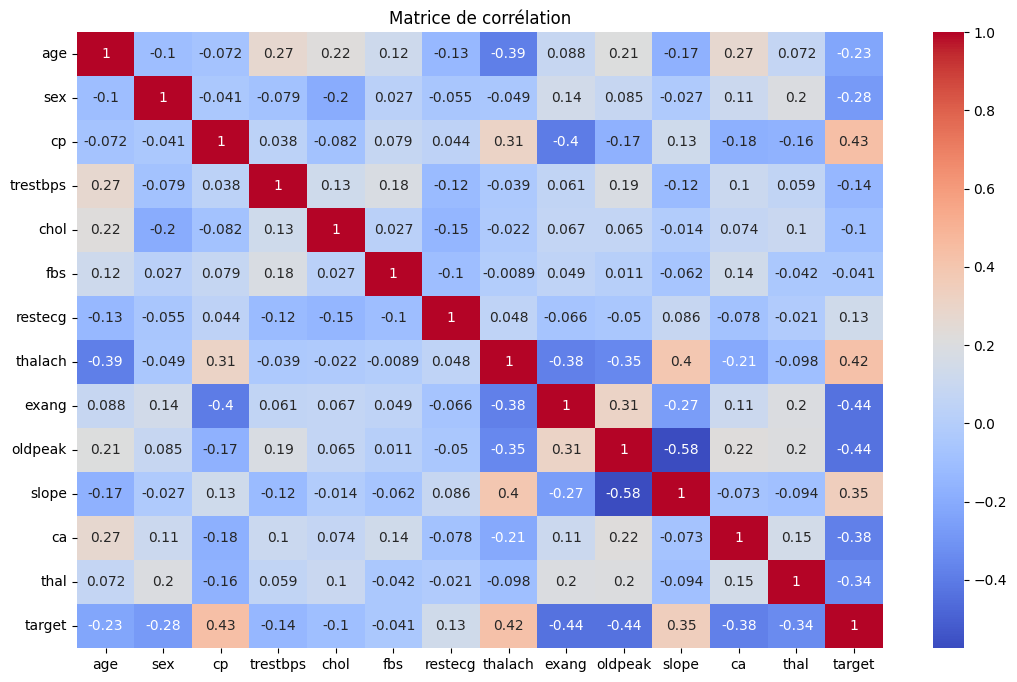

In [ ]:
plt.figure(figsize=(13,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

In [40]:
% cd ls /content/drive/MyDrive/Colab\ Notebooks/MesProjets/Datasetheart.ipynb

'/content/drive/MyDrive/Colab Notebooks/MesProjets/Datasetheart.ipynb'


In [42]:
!git config --global user.name "Merveille Christamour CODJO"
!git config --global user.email "mcodjo04@gmail.com"


In [43]:
!rm -rf .git
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Colab Notebooks/.git/


In [44]:
!git add .

In [45]:
!git commit -m "Premier commit propre depuis Colab"


[master (root-commit) 81c5a6c] Premier commit propre depuis Colab
 8 files changed, 117081 insertions(+)
 create mode 100644 MesProjets/Datasetheart.ipynb
 create mode 100644 MesProjets/sales_data.csv
 create mode 100644 predic/result.zip
 create mode 100644 predic/result_unzipped/migrations.csv
 create mode 100644 predic/result_unzipped/properties.csv
 create mode 100644 predic/result_unzipped/property_galleries.csv
 create mode 100644 predic/result_unzipped/roles.csv
 create mode 100644 predic/result_unzipped/visits.csv


In [46]:
!git branch -M main

In [49]:
!git remote add origin https://github.com/mcodjo04-cam/heart-disease-analysis.git


error: remote origin already exists.


In [50]:
!git push -u origin main

Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (13/13), done.
Writing objects: 100% (13/13), 1.52 MiB | 2.32 MiB/s, done.
Total 13 (delta 0), reused 0 (delta 0), pack-reused 0
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote:       —— GitHub Personal Access Token ——————————————————————
remote:        locations:
remote:          - commit: 81c5a6c42a4bb36e9a27d13f0a53d74c8e